# Eksperimen Machine Learning - Titanic Dataset
**Nama:** BayuBimantara
**Dataset:** Titanic Dataset (Kaggle)
**Problem:** Binary Classification (Survived or Not)

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")

Library berhasil diimport!


## 2. Data Loading

In [2]:
df = pd.read_csv('../Titanic-Dataset.csv')
print("Shape dataset:", df.shape)
print("\n5 baris pertama:")
df.head()

Shape dataset: (891, 12)

5 baris pertama:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("=== INFO DATASET ===")
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
print("=== STATISTIK DESKRIPTIF ===")
df.describe()

=== STATISTIK DESKRIPTIF ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print("=== CEK MISSING VALUES ===")
print(df.isnull().sum())

=== CEK MISSING VALUES ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
print("=== DISTRIBUSI TARGET (Survived) ===")
print(df['Survived'].value_counts())

=== DISTRIBUSI TARGET (Survived) ===
Survived
0    549
1    342
Name: count, dtype: int64


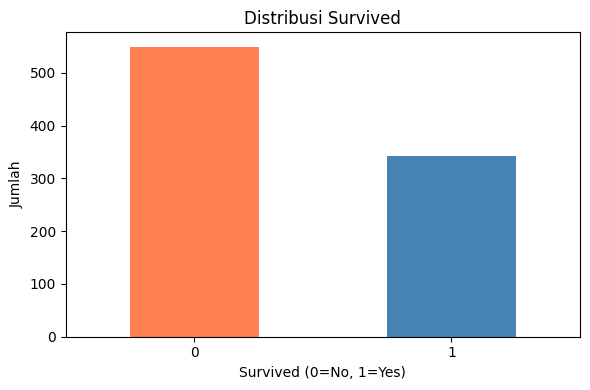

Plot disimpan!


In [7]:
plt.figure(figsize=(6,4))
df['Survived'].value_counts().plot(kind='bar', color=['coral','steelblue'])
plt.title('Distribusi Survived')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('survived_distribution.png')
plt.show()
print("Plot disimpan!")

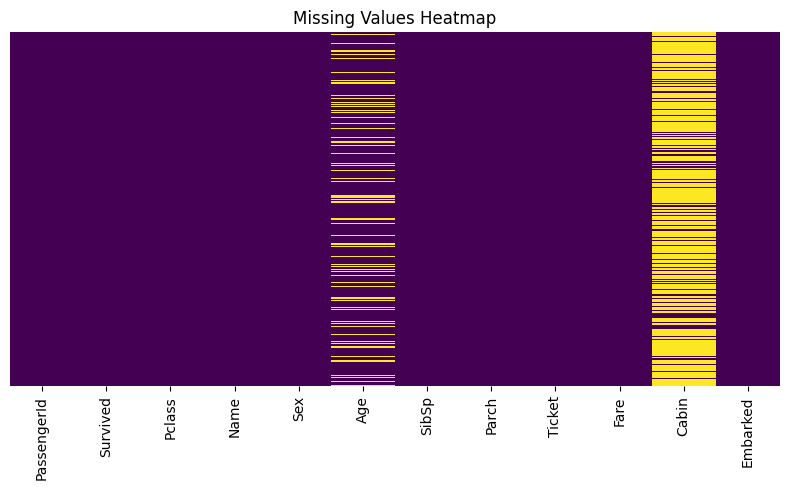

In [8]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.savefig('missing_values.png')
plt.show()

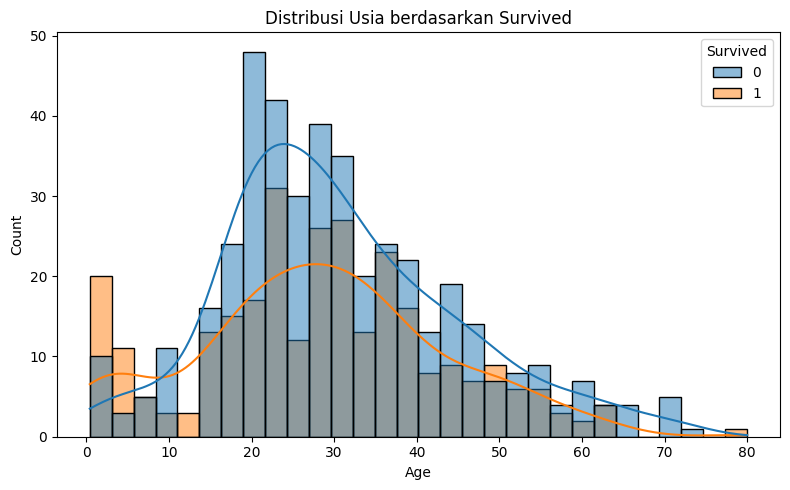

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Distribusi Usia berdasarkan Survived')
plt.tight_layout()
plt.savefig('age_distribution.png')
plt.show()

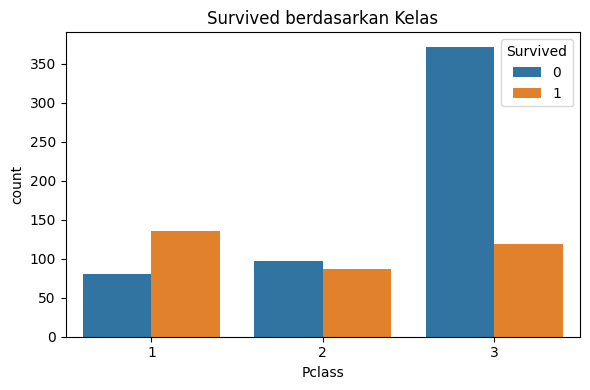

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survived berdasarkan Kelas')
plt.tight_layout()
plt.savefig('pclass_survived.png')
plt.show()

## 4. Data Preprocessing

In [11]:
# 4.1 Drop kolom yang tidak relevan
df_clean = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
print("Kolom setelah drop:", df_clean.columns.tolist())

Kolom setelah drop: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [12]:
# 4.2 Handle missing values
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)
print("Missing values setelah handling:")
print(df_clean.isnull().sum())

Missing values setelah handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [13]:
# 4.3 Encoding kolom kategorikal
le = LabelEncoder()
df_clean['Sex'] = le.fit_transform(df_clean['Sex'])
df_clean['Embarked'] = le.fit_transform(df_clean['Embarked'])
print("Encoding selesai!")
df_clean.head()

Encoding selesai!


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [14]:
# 4.4 Pisahkan fitur dan target
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df_clean[feature_cols]
y = df_clean['Survived']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (891, 7)
Shape y: (891,)


In [15]:
# 4.5 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (712, 7) Test: (179, 7)


In [16]:
# 4.6 Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

print("Scaling selesai!")
X_train_scaled.head()

Scaling selesai!


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.829568,0.742427,-0.112078,-0.465084,-0.466183,0.513812,0.584892
1,-0.370945,0.742427,-0.112078,-0.465084,-0.466183,-0.662563,0.584892
2,-1.571457,0.742427,-0.112078,-0.465084,-0.466183,3.955399,0.584892
3,0.829568,-1.346933,-0.879807,-0.465084,0.727782,-0.467874,0.584892
4,-0.370945,-1.346933,0.118241,0.478335,0.727782,-0.115977,0.584892


In [17]:
# 4.7 Simpan hasil preprocessing
import os
os.makedirs('../preprocessing', exist_ok=True)

train_preprocessed = X_train_scaled.copy()
train_preprocessed['Survived'] = y_train.values

test_preprocessed = X_test_scaled.copy()
test_preprocessed['Survived'] = y_test.values

train_preprocessed.to_csv('../preprocessing/titanic_preprocessing_train.csv', index=False)
test_preprocessed.to_csv('../preprocessing/titanic_preprocessing_test.csv', index=False)

print("Dataset preprocessing disimpan!")
print("Train:", train_preprocessed.shape)
print("Test:", test_preprocessed.shape)

Dataset preprocessing disimpan!
Train: (712, 8)
Test: (179, 8)


## 5. Quick Model Validation

In [18]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("=== HASIL QUICK VALIDATION ===")
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

=== HASIL QUICK VALIDATION ===
              precision    recall  f1-score   support

Not Survived       0.84      0.89      0.86       110
    Survived       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



In [19]:
print("✅ Eksperimen selesai! Dataset sudah siap untuk tahap modelling.")

✅ Eksperimen selesai! Dataset sudah siap untuk tahap modelling.
